In [1]:
!pip --version

pip 26.2.1 from D:\jh0902\ex0914\.venv\Lib\site-packages\pip (python 3.12)



In [ ]:
# !pip install -U langchain langchain-openai

  Using cached langchain-1.4.0-py3-none-any.whl.metadata (6.2 kB)
  Using cached langgraph-1.2.11-py3-none-any.whl.metadata (4.9 kB)
  Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached ormsgpack-1.12.2-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached websockets-16.1.1-cp312-cp312-win_amd64.whl.metadata (7.0 kB)
Using cached langchain-1.4.0-py3-none-any.whl (161 kB)
Using cached langgraph-1.2.11-py3-none-any.whl (248 kB)
Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl (56 kB)
Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl (41 kB)
Using cached langgraph_sdk-0.4.4-py3-none-any.whl (162 kB)
Using cached websockets-16.1.1-cp312-cp312-win_amd64.whl (180 kB)
Using cached ormsgpack-1.12.2-cp312-cp312-win_amd64.whl (117 kB)

  Attempting uninstall: websockets

    Found existing install

In [1]:

from dotenv import load_dotenv
import os

# .env 파일 로드 (override=False가 기본값이므로 시스템 환경변수가 우선순위를 가집니다)
load_dotenv()

# 정상 로드 확인 테스트
print("OpenAI 키:", os.getenv("OPENAI_API_KEY")[:8] + "...")
print("LANGSMITH 키:", os.getenv("LANGSMITH_API_KEY")[:8] + "...")
print("LangSmith 프로젝트:", os.getenv("LANGSMITH_PROJECT"))

OpenAI 키: sk-proj-...
LANGSMITH 키: lsv2_pt_...
LangSmith 프로젝트: test0914


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
response = llm.invoke("수도가 서울인 국가는 어디인가요?")
print(response.content)

수도가 서울인 국가는 대한민국입니다.


In [7]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent

@tool
def get_weather(city: str) -> str:
    """특정 도시의 날씨 가져오기"""
    return f"It's always sunny in {city}!"

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
agent = create_agent(model=llm, tools=[get_weather])

result = agent.invoke({"messages": [("user", "천안 날씨 어때?")]})
print(result["messages"][-1].content)

천안의 날씨는 항상 맑습니다!


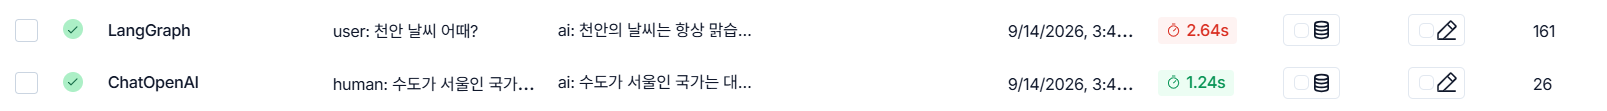

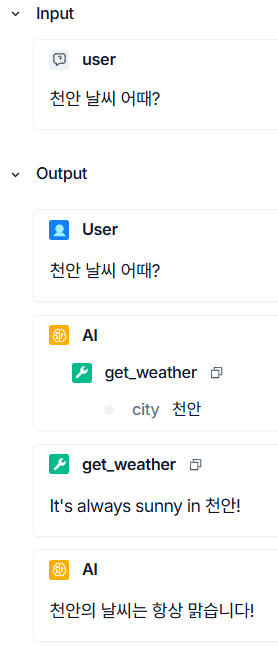